# Python Machine Learning client for SAP HANA, release 2.22 enhancements sample notebook

The changelog of enhancements with the release version 2.22.240917 can be found [in the documentation](https://help.sap.com/doc/cd94b08fe2e041c2ba778374572ddba9/2024_3_QRC/en-US/change_log.html), and are summaried below  <br><br>
__New functions__<br>
    - Outlier Detection for regression:  `hana_ml.algorithms.pal.preprocessing.OutlierDetectionRegression`.  <br>
    - Multi-task MLP Classification and Regression model: `hana_ml.algorithms.pal.neural_network.MLPMultiTaskClassifier` and `MLPMultiTaskRegressor`. <br>
    - Model Card creation and parser fucntion: `hana_ml.algorithms.pal.model_cards.create_model_card` and `parse_model_card`. <br>
    - ConnectionContext `to_sqlalchemy` function. <br>
    - AutoML massive model functions: `hana_ml.algorithms.pal.massive_auto_ml.MassiveAutomaticClassification`, `MassiveAutomaticRegression` and `MassiveAutomaticTimeSeries`. <br>
<br>
__Enhancements__<br>
    - Enhanced dataset report with new style. <br>
    - Enhanced model storage with model card integration. <br>
    - Enhanced make_future_dataframe with increment_type option. <br>
    - Enhanced hana_scheduler to support the schema of the output tables. <br>
    - Enhanced json pipeline input in Pipeline Module. <br>
    - Enhanced Text classification with model TextClassificationWithModel. <br>
<br>

## Connect to your SAP HANA Cloud instance

The latest Python ML client for SAP HANA package update is ready for installation and can be found at: https://pypi.org/project/hana-ml/

In [1]:
## Loading the Python Machine Learning client library for SAP HANA and get the version
import hana_ml
print(hana_ml.__version__)

2.30.26091504


Connect using the secure user connection store (hdbuserstore) and a connection key, see  [documentation](https://help.sap.com/docs/SAP_HANA_CLIENT/f1b440ded6144a54ada97ff95dac7adf/708e5fe0e44a4764a1b6b5ea549b88f4.html).  

In [2]:
# Create the SAP HANA CLoud connection
import hana_ml.dataframe as dataframe
#cc = dataframe.ConnectionContext( address="<hana-cloud-hostname>", port=443,  user="<HANA-user>", sslValidateCertificate=False)
#cc = dataframe.ConnectionContext( userkey=<your-key-name>, sslValidateCertificate=False)

# Utilize connection credentials from external file
from hana_ml.dataframe import ConnectionContext
from hana_ml.algorithms.pal.utility import Settings
url, port, user, pwd = Settings.load_config("../../config/e2edata.ini", "hana")
cc = ConnectionContext(url, port, user, pwd, sslValidateCertificate=False)

#cc = ConnectionContext(userkey='<your-key-name>')

# Control connection
print(cc.connection.isconnected())
print(cc.hana_version())

True
4.00.000.00.1786441019 (fa/CE2026.28)


## Re-use SAP HANA Cloud connection with SQLAlchemy
For a project overview see [sqlalchemy-hana](https://pypi.org/project/sqlalchemy-hana/), for the project on github see [github.com/SAP/sqlalchemy-hana](https://github.com/SAP/sqlalchemy-hana).

In [5]:
# Python install sqlalchemy and sqlalchemy-hana required

# Use the ConnectionContext method 'to_sqlalchemy'
hana_engine = cc.to_sqlalchemy()
type(hana_engine)

# Using sqlalchemy for hana
from sqlalchemy import Column, Integer, MetaData, String, Table, select, inspect 
metadata = MetaData()
sqla_table = Table('#MY_SQLALCHEMY_TABLE', metadata, Column('id', Integer), hana_table_type = 'COLUMN')
print(select(sqla_table))


SELECT "#MY_SQLALCHEMY_TABLE".id 
FROM "#MY_SQLALCHEMY_TABLE"


## AutoML enhancements
The SAP HANA Cloud __Predictive Analysis Library (PAL)__ provide new SQL functions for [data-parallel AutoML](https://help.sap.com/docs/hana-cloud-database/sap-hana-cloud-sap-hana-database-predictive-analysis-library/massive-interface-automl-massive-interface?locale=en-US) and [ML Pipeline](https://help.sap.com/docs/hana-cloud-database/sap-hana-cloud-sap-hana-database-predictive-analysis-library/massive-interface-automl-massive-interface?locale=en-US) modeling, also documented in the Python interface for [AutoML](https://help.sap.com/doc/cd94b08fe2e041c2ba778374572ddba9/2024_3_QRC/en-US/pal/algorithms.html#auto-ml) and [Pipeline](https://help.sap.com/doc/cd94b08fe2e041c2ba778374572ddba9/2024_3_QRC/en-US/pal/algorithms/hana_ml.algorithms.pal.pipeline.Pipeline.html) methods by applying the group_key-parameter to identify the data subgroups.


### Data-parallel (massive) AutoML TimeSeries modeling
For a copy of the sample data see [github.com/SAP-samples/hana-ml-samples/Python-API/usecase-examples/usecase-example-datasets/shampoo_sales.csv](https://github.com/SAP-samples/hana-ml-samples/blob/main/Python-API/usecase-examples/usecase-example-datasets/shampoo_sales.csv)

In [8]:
# Use case dataset: 2 time series data for 2 different shampoo product sales over 3 years
# Upload a dataset from local CSV-file 
import pandas as pd
from hana_ml.dataframe import create_dataframe_from_pandas
shampoo_hdf = create_dataframe_from_pandas(cc,
                                            pd.read_csv("../../usecase-examples/usecase-example-datasets/shampoo_sales.csv", header=1, names=["MONTH", "PRODUCT", "PRODUCT_ID", "SALES"]),
                                            table_name="SHAMPOO_SALES",
                                            force=True,
                                            table_structure={"MONTH": "INTEGER", "PRODUCT": "NVARCHAR(32)", "PRODUCT_ID": "INTEGER", "SALES": "DOUBLE"})
print(shampoo_hdf.select_statement)
display(shampoo_hdf.sort("MONTH").head(5).collect())

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 17.07it/s]


SELECT * FROM "SHAMPOO_SALES"


,MONTH,PRODUCT,PRODUCT_ID,SALES
0,1,Classic Shampoo,1,646.9
1,1,New Shampoo,2,266.0
2,2,New Shampoo,2,145.9
3,2,Classic Shampoo,1,581.3
4,3,Classic Shampoo,1,475.3


In [9]:
# Modeling time series for 'Classic Shampoo' and 'New Shampoo' in parallel
from hana_ml.algorithms.pal.massive_auto_ml import MassiveAutomaticTimeSeries
Segmented_AutoTS = MassiveAutomaticTimeSeries(
                              generations=30, population_size=25, offspring_size=15, 
                              early_stop=1, max_eval_time_mins=1, 
                              scorings={'RMSE': -1},
                              elite_number=10,
                              search_method='random', connections='default'
                             ,config_dict='default')

Segmented_AutoTS.enable_workload_class(workload_class_name="AUTOML_WLC")

Segmented_AutoTS.fit(data=shampoo_hdf.deselect("PRODUCT_ID"), group_key='PRODUCT',  key='MONTH', endog="SALES")


In [10]:
# Inspect the elite pipelines from the best result dataframe
Segmented_AutoTS.best_pipeline_.collect().style.set_properties(**{'text-align': 'left'})


,PRODUCT,ID,PIPELINE,SCORES
0,New Shampoo,0,"{""BrownExpSm"":{""args"":{""ALPHA"":0.6},""inputs"":{""data"":""ROWDATA""}}}","{""EVAR"":0.0204164433902281,""LAYERS"":1.0,""MAE"":65.41929239999999,""MAPE"":0.20064643528808294,""MAX_ERROR"":140.9359228,""MSE"":6439.157458742115,""R2"":-0.5124661153515719,""RMSE"":78.065877717262,""SPEC"":74.5494903833333,""TIME"":0.0014,""WMAPE"":0.20712778718416037}"
1,New Shampoo,1,"{""BSTS"":{""args"":{""BURN_IN"":0.1,""SEASONAL_PERIOD"":-1},""inputs"":{""data"":""ROWDATA""}}}","{""EVAR"":-0.18055774833315178,""LAYERS"":1.0,""MAE"":73.73846,""MAPE"":0.2531277833769451,""MAX_ERROR"":151.0248204,""MSE"":9367.101186524305,""R2"":-1.1751821100730562,""RMSE"":87.86119005535622,""SPEC"":108.34763426666669,""TIME"":0.5640000000000001,""WMAPE"":0.23630341439315587}"
2,New Shampoo,2,"{""BSTS"":{""args"":{""BURN_IN"":0.2,""SEASONAL_PERIOD"":-1},""inputs"":{""data"":""ROWDATA""}}}","{""EVAR"":-0.10913473733255883,""LAYERS"":1.0,""MAE"":74.08959483333334,""MAPE"":0.24851609619917054,""MAX_ERROR"":153.59322740000003,""MSE"":9781.464539941842,""R2"":-1.170410996142198,""RMSE"":88.80015268127554,""SPEC"":114.03890231666665,""TIME"":1.4007999999999999,""WMAPE"":0.23324915467039174}"
3,New Shampoo,3,"{""BSTS"":{""args"":{""BURN_IN"":0.5,""SEASONAL_PERIOD"":-1},""inputs"":{""data"":""ROWDATA""}}}","{""EVAR"":-0.14888865863465323,""LAYERS"":1.0,""MAE"":74.99665506666666,""MAPE"":0.2506661515364256,""MAX_ERROR"":152.331797,""MSE"":9819.021370154362,""R2"":-1.1715202983188836,""RMSE"":89.10283310935582,""SPEC"":112.83993458333335,""TIME"":0.7882,""WMAPE"":0.2367485333599224}"
4,New Shampoo,4,"{""BSTS"":{""args"":{""BURN_IN"":0.4,""SEASONAL_PERIOD"":-1},""inputs"":{""data"":""ROWDATA""}}}","{""EVAR"":-0.14674322283741948,""LAYERS"":1.0,""MAE"":75.12064229999999,""MAPE"":0.25196184954731418,""MAX_ERROR"":153.59023059999999,""MSE"":9890.760115184996,""R2"":-1.1915158241030839,""RMSE"":89.49115101565822,""SPEC"":114.26283299999993,""TIME"":0.8161999999999999,""WMAPE"":0.23735771772847959}"
5,New Shampoo,5,"{""TSFM"":{""args"":{""BATCH_SIZE"":128,""POINT_FORECAST"":""median""},""inputs"":{""data"":""ROWDATA""}}}","{""EVAR"":0.013751514708589064,""LAYERS"":1.0,""MAE"":75.01127346666667,""MAPE"":0.20921562180122148,""MAX_ERROR"":160.0748882,""MSE"":9246.410291011305,""R2"":-1.1930388153909602,""RMSE"":92.35920339592596,""SPEC"":106.29630291666664,""TIME"":0.028599999999999998,""WMAPE"":0.2266863162975771}"
6,New Shampoo,6,"{""ARIMA"":{""args"":{""SEASONALITY_CRITERION"":0.9,""SEASONAL_PERIOD"":-1,""INFORMATION_CRITERION"":0,""KPSS_SIGNIFICANCE_LEVEL"":0.025,""D"":-1,""MAX_SEASONAL_D"":1,""MAX_D"":3,""CH_SIGNIFICANCE_LEVEL"":0.2,""SEASONAL_D"":-1},""inputs"":{""data"":""ROWDATA""}}}","{""EVAR"":0.04114586086970804,""LAYERS"":1.0,""MAE"":79.22105653333333,""MAPE"":0.22076221375452205,""MAX_ERROR"":166.112173,""MSE"":10316.137355263298,""R2"":-1.2974133529186923,""RMSE"":95.6842047231933,""SPEC"":118.86285401666669,""TIME"":1.9676000000000003,""WMAPE"":0.2366994922288343}"
7,New Shampoo,7,"{""AutoExpSm"":{""args"":{""TREND_TEST_METHOD"":1,""TREND_TEST_ALPHA"":0.1,""MODELSELECTION"":1,""MAX_ITERATION"":1000},""inputs"":{""data"":""ROWDATA""}}}","{""EVAR"":-0.029324300430934436,""LAYERS"":1.0,""MAE"":81.60836546666667,""MAPE"":0.22517587189674857,""MAX_ERROR"":162.92779499999998,""MSE"":11290.726061249738,""R2"":-1.3999948646015768,""RMSE"":97.10705983481383,""SPEC"":117.61198053333331,""TIME"":0.149,""WMAPE"":0.2369918860835948}"
8,New Shampoo,8,"{""BrownExpSm"":{""args"":{""ALPHA"":0.1},""inputs"":{""data"":""ROWDATA""}}}","{""EVAR"":0.005648922413998325,""LAYERS"":1.0,""MAE"":86.53472243333333,""MAPE"":0.23207384053800488,""MAX_ERROR"":176.832335,""MSE"":12637.322383805073,""R2"":-1.7538853536806738,""RMSE"":104.61319911400878,""SPEC"":138.92681898333337,""TIME"":0.0014,""WMAPE"":0.249733781685645}"
9,New Shampoo,9,"{""AMTSA"":{""args"":{""GROWTH"":""linear"",""NUM_CHANGEPOINTS"":5},""inputs"":{""data"":""ROWDATA""}}}","{"

In [11]:
# Prepare a predict dataframe to calculate the forecast horizon for the next n periods, here next 10 months
predict_frame = Segmented_AutoTS.make_future_dataframe(periods=10)
display(predict_frame.sort("MONTH").head(5).collect())

,PRODUCT,MONTH
0,Classic Shampoo,36
1,Classic Shampoo,37
2,New Shampoo,37
3,Classic Shampoo,38
4,New Shampoo,38


In [12]:
# Forecast the Shampoo Product Sales for different products
predict_result = Segmented_AutoTS.predict(predict_frame, group_key='PRODUCT', key='MONTH')
predict_result.collect()

,PRODUCT,ID,SCORES
0,New Shampoo,37,676.690905
1,New Shampoo,38,716.105548
2,New Shampoo,39,755.520190
3,New Shampoo,40,794.934832
4,New Shampoo,41,834.349474
5,New Shampoo,42,873.764117
6,New Shampoo,43,913.178759
7,New Shampoo,44,952.593401
8,New Shampoo,45,992.008043
9,New Shampoo,46,1031.422686


In [13]:
#print(cc.last_execute_statement)

### JSON input to Pipeline function
The pipeline JSON string object can be passed into the Pipeline-methods as a captured JSON (get_best_pipeline-method) or manually composed and passed into the Pipeline-fit method.

In [14]:
# Capture the best pipeline as JSON (A) (JSON method string)
mybestpipeline=Segmented_AutoTS.get_best_pipeline()
display(mybestpipeline)
import json
mybestpipeline_json = json.loads(mybestpipeline['New Shampoo']) #unquote and format the json string
mybestpipeline_json

{'New Shampoo': '{"BrownExpSm":{"args":{"ALPHA":0.6},"inputs":{"data":"ROWDATA"}}}',
 'Classic Shampoo': '{"BrownExpSm":{"args":{"ALPHA":0.1},"inputs":{"data":"ROWDATA"}}}'}

{'BrownExpSm': {'args': {'ALPHA': 0.6}, 'inputs': {'data': 'ROWDATA'}}}

In [15]:
# Build Pipeline Model with JSON Pipeline-Input
from hana_ml.algorithms.pal.pipeline import Pipeline
shampoo_fit_hdf=shampoo_hdf.filter('PRODUCT = \'New Shampoo\'').select('MONTH', 'SALES').rearrange(key='MONTH', label='SALES', type_ts=True)
#display(shampoo_fit_hdf.head(5).collect())

my_pl=Pipeline(pipeline=mybestpipeline_json) 

res = my_pl.fit(data=shampoo_fit_hdf, key='MONTH',  endog="SALES" , use_pal_pipeline_fit=True)
#print(res)

display(my_pl.model_.collect())

,ROW_INDEX,MODEL_CONTENT
0,0,"{""pipeline"":{""BrownExpSm"":{""args"":{""ALPHA"":0.6..."


In [16]:
# Run Forecast with the pipeline-predict method
pipeline_forecast=my_pl.predict(predict_frame.filter('PRODUCT = \'New Shampoo\'').deselect("PRODUCT" ), key="MONTH")
display(pipeline_forecast.collect())

,ID,SCORES
0,37,676.690905
1,38,716.105548
2,39,755.520190
3,40,794.934832
4,41,834.349474
5,42,873.764117
6,43,913.178759
7,44,952.593401
8,45,992.008043
9,46,1031.422686


## New Machine Learning model card management
Model cards are an important documentation framework for understanding, sharing, and improving machine learning models. A model card is a short document that provides key information about a machine learning model. Model cards increase transparency in documentating various aspects of a ML model, for example incl. input data schema. For more information about model cards see [huggingface.co/model-cards](https://huggingface.co/blog/model-cards).

In [17]:
from hana_ml.algorithms.pal.model_cards import create_model_card

model_card = create_model_card(Segmented_AutoTS)

In [18]:
print(model_card)

---
datasets:
  training_data: SELECT "MONTH", "PRODUCT", "SALES" FROM (SELECT * FROM "SHAMPOO_SALES")
    AS "DT_3"
  training_data_signature:
    MONTH: INT
    PRODUCT: NVARCHAR(32)
    SALES: DOUBLE
language: en
library_name: hana_ml.algorithms.pal.massive_auto_ml.MassiveAutomaticTimeSeries
license: SAP Developer License Agreement
metrics:
  model_metrics: '{"BrownExpSm":{"args":{"ALPHA":0.6},"inputs":{"data":"ROWDATA"}}}'
model_version: 1
---

# Model Card for Model ID

<!-- Provide a quick summary of what the model is/does. -->



## Model Details

### Model Description

<!-- Provide a longer summary of what this model is. -->



- **Developed by:** [More Information Needed]
- **Funded by [optional]:** [More Information Needed]
- **Shared by [optional]:** [More Information Needed]
- **Model type:** [More Information Needed]
- **Language(s) (NLP):** en
- **License:** SAP Developer License Agreement
- **Finetuned from model [optional]:** [More Information Needed]

### Model Sources

In [19]:
# Store the HANA ML model using ModelStorage and retrieve model card information from Model Storage
from hana_ml.model_storage import ModelStorage

model_storage = ModelStorage(cc)

model_storage.clean_up()

Segmented_AutoTS.name = "Segmented Shampoo Produce Sales TS Model"
Segmented_AutoTS.version = 1

model_storage.save_model(model=Segmented_AutoTS)

In [20]:
model_card = model_storage.get_model_card(name="Segmented Shampoo Produce Sales TS Model", version=1)
model_card.data

{'datasets': {'training_data': 'SELECT "MONTH", "PRODUCT", "SALES" FROM (SELECT * FROM "SHAMPOO_SALES") AS "DT_3"', 'training_data_signature': {'MONTH': 'INT', 'PRODUCT': 'NVARCHAR(32)', 'SALES': 'DOUBLE'}}, 'language': 'en', 'library_name': 'hana_ml.algorithms.pal.massive_auto_ml.MassiveAutomaticTimeSeries', 'license': 'SAP Developer License Agreement', 'metrics': {'model_metrics': '{"BrownExpSm":{"args":{"ALPHA":0.6},"inputs":{"data":"ROWDATA"}}}'}, 'model_version': 1}

In [21]:
# Retrieve the model card information from a model loaded from Model Storage
from hana_ml.algorithms.pal.model_cards import parse_model_card

my_model = model_storage.load_model(name="Segmented Shampoo Produce Sales TS Model", version=1)
my_model_card = parse_model_card(my_model.model_card_)

my_model_card.data

{'datasets': {'training_data': 'SELECT "MONTH", "PRODUCT", "SALES" FROM (SELECT * FROM "SHAMPOO_SALES") AS "DT_3"', 'training_data_signature': {'MONTH': 'INT', 'PRODUCT': 'NVARCHAR(32)', 'SALES': 'DOUBLE'}}, 'language': 'en', 'library_name': 'hana_ml.algorithms.pal.massive_auto_ml.MassiveAutomaticTimeSeries', 'license': 'SAP Developer License Agreement', 'metrics': {'model_metrics': '{"BrownExpSm":{"args":{"ALPHA":0.6},"inputs":{"data":"ROWDATA"}}}'}, 'model_version': 1}

## New multi-task MLP Neural Network
The new __multi-task Multi-Layer Perceptron (MLP)__ for __multi-label classification__ or __multi-target regression__ scenarios allows with a single neural network to model and predict multiple, related target columns at once using a single model. It captures both common features across tasks as well as the task-specific information within a single Neural Network prediction model. See details about the new function in the [SQL documentation](https://help.sap.com/docs/hana-cloud-database/sap-hana-cloud-sap-hana-database-predictive-analysis-library/multi-task-multilayer-perceptron?locale=en-US) as well as the Python methods [MLPMultiTaskClassifier](https://help.sap.com/doc/cd94b08fe2e041c2ba778374572ddba9/2024_3_QRC/en-US/pal/algorithms/hana_ml.algorithms.pal.neural_network.MLPMultiTaskClassifier.html) [MLPMultiTaskRegressor](https://help.sap.com/doc/cd94b08fe2e041c2ba778374572ddba9/2024_3_QRC/en-US/pal/algorithms/hana_ml.algorithms.pal.neural_network.MLPMultiTaskRegressor.html).

### Multi-Label Classifier MLP
For a copy of the sample data see [github.com/SAP-samples/hana-ml-samples/.../diabetes_pnp.csv](https://github.com/SAP-samples/hana-ml-samples/blob/main/Python-API/usecase-examples/usecase-example-datasets/diabetes_pnp.csv)

In [23]:
# In this multi-label classification model, we seek to predict Diabetes and Peripheral NeuroPathy (PNP) from patient data
# Upload a dataset from local CSV-file 
import pandas as pd
hdf = dataframe.create_dataframe_from_pandas(cc,
                                            pd.read_csv("../../usecase-examples/usecase-example-datasets/diabetes_pnp.csv"),
                                            table_name="DIABETES_PNP",
                                            force=True)
print(hdf.select_statement)
print(hdf.columns)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.86it/s]

SELECT * FROM "DIABETES_PNP"
['ID', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diabetes', 'PNP']


In [24]:
# Splitting the input data into train- and test-subset
from hana_ml.algorithms.pal.partition import train_test_val_split
hdf_train, hdf_test, _ = train_test_val_split(data=hdf, 
                                            random_seed=2,
                                            partition_method = 'stratified',
                                            stratified_column = 'PNP',
                                            training_percentage=0.75,
                                            testing_percentage=0.25,
                                            validation_percentage=0)

In [25]:
# MLPMultiTaskClassifier, fitting the model
from hana_ml.algorithms.pal.neural_network import MLPMultiTaskClassifier

label = ['Diabetes','PNP']

ml = MLPMultiTaskClassifier(activation='relu',
                    hidden_layer_size=(2, 3),
                    learning_rate=0.00123,
                    batch_size=10)

ml.fit(data=hdf_train, key='ID', label=label)
ml.runtime

0.5520079135894775

In [26]:
# Predict Diabetes and PNP with the test-data at once
ml.predict(data=hdf_test.drop(label), key='ID').collect()

,ID,TARGET,SCORE,CONFIDENCE
0,4,PNP,0,1.000000
1,4,Diabetes,0,0.907536
2,5,PNP,0,1.000000
3,5,Diabetes,1,0.868585
4,11,PNP,0,1.000000
...,...,...,...,...
379,753,Diabetes,0,0.907536
380,754,PNP,0,1.000000
381,754,Diabetes,0,0.538463
382,762,PNP,0,1.000000


### Multi-Target Regressor MLP
For a copy of the sample data see [github.com/SAP-samples/hana-ml-samples/.../SBOOK_TICKETPRICE.csv](https://github.com/SAP-samples/hana-ml-samples/blob/main/Python-API/usecase-examples/usecase-example-datasets/SBOOK_TICKETPRICE.csv)

In [27]:
# In this multi-target regression scenario, we seek to predict airline ticket prices at different numbers of days prior to the flight
# Upload a dataset from local CSV-file 
import pandas as pd
hdf = dataframe.create_dataframe_from_pandas(cc,
                                            pd.read_csv("../../usecase-examples/usecase-example-datasets/SBOOK_TICKETPRICE.csv"),
                                            table_name="SBOOK_TICKETPRICE",
                                            force=True)
hdfid = hdf.add_id(id_col='ID').deselect('INVOICE')

#print(hdfid.select_statement)
print(hdfid.columns)
#hdfid.describe().collect()
#hdfid.head(10).collect()

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:06<00:00,  6.01s/it]

['ID', 'BOOKID', 'ORDER_DATE', 'CARRID', 'CONNID', 'FLDATE', 'WEEKDAY', 'MONTH', 'DAYS_BOOKED_AHEAD', 'LUGGWEIGHT', 'CUSTTYPE', 'COUNTER', 'AGENCYNUM', 'COUNTRYFR', 'CITYFROM', 'AIRPFROM', 'COUNTRYTO', 'CITYTO', 'AIRPTO', 'FLTIME', 'DEPTIME', 'ARRTIME', 'PERIOD', 'CLASS', 'BOOKED_PRICE', 'TPRICE_180N', 'TPRICE_90N', 'TPRICE_30N', 'TPRICE_7N']


In [28]:
# Splitting the input data into train- and test-subset
from hana_ml.algorithms.pal.partition import train_test_val_split
hdf_train, hdf_test, _ = train_test_val_split(data=hdfid, 
                                            random_seed=2,
                                            training_percentage=0.75,
                                            testing_percentage=0.25,
                                            validation_percentage=0)

In [29]:
# MLPMultiTaskRegressor, fitting the MLP regression model
from hana_ml.algorithms.pal.neural_network import MLPMultiTaskRegressor

targets = ['BOOKED_PRICE', 'TPRICE_180N', 'TPRICE_90N', 'TPRICE_30N', 'TPRICE_7N']

mlpr = MLPMultiTaskRegressor(hidden_layer_size=(5,5), activation='relu', batch_size=5, learning_rate=0.3, 
                             patience=5, optimizer='adam', random_state=1234, training_percentage=0.9)
mlpr.fit(hdf_train, 'ID', label=targets)
display(mlpr.runtime)


25.49129295349121

In [30]:
# Displaying MLPMultiTaskRegressor model-object attributes
display(mlpr.model_.collect())
display(mlpr.train_log_.collect())
display(mlpr.stats_.collect())
#display(mlpr.optim_param_.collect())

,ROW_INDEX,PART_INDEX,MODEL_CONTENT
0,0,-1,"{""feature_names"":[""BOOKID"",""ORDER_DATE"",""CONNI..."
1,1,0,"{""Matrices"":[{""nRows"":64,""nCols"":5,""Elements"":..."
2,2,0,"8028,-0.576584,20.404908,8.55799,20.11001,10.6..."
3,3,0,",-91.545769,-77.630383,-84.68052,-91.029183,-8..."
4,4,0,"486874,-45.669019,-66.618156,-50.250136,-61.67..."
...,...,...,...
82,82,0,"5,0.12953,0.154784,0.107021,0.086851,0.019259,..."
83,83,0,",-1.194243,-1.202627,-1.210524,-1.151507,-1.22..."
84,84,0,".082786,-1.160228,-1.140136,-1.195231,-1.22601..."
85,85,0,"214303,-1.24168,-1.315498,-1.335691,-1.356166,..."


,ITERATION,ERROR
0,0,905248.963203
1,1,65721.611781
2,2,41440.820290
3,3,36454.603493
4,4,47724.834250
...,...,...
96,96,81300.421868
97,97,72682.485288
98,98,58566.382802
99,99,60843.629345


,STAT_NAME,STAT_VALUE
0,BEST_EPOCH,3


In [31]:
# Predicting the ticket prices at different number of days prior to the flight with the test-data
res = mlpr.predict(hdf_test.drop(targets), key='ID')
display(res.deselect('CONFIDENCE').collect())

,ID,TARGET,SCORE
0,9,TPRICE_90N,659.339
1,9,TPRICE_180N,618.827
2,9,BOOKED_PRICE,686.849
3,9,TPRICE_7N,721.773
4,9,TPRICE_30N,699.611
...,...,...,...
34595,27679,TPRICE_90N,1312.19
34596,27679,TPRICE_180N,1225.72
34597,27679,BOOKED_PRICE,1360.07
34598,27679,TPRICE_7N,1428.11


## New Dataset report style

For a copy of the sample data see [github.com/SAP-samples/hana-ml-samples/.../SBOOK_TICKETPRICE.csv](https://github.com/SAP-samples/hana-ml-samples/blob/main/Python-API/usecase-examples/usecase-example-datasets/SBOOK_TICKETPRICE.csv)

In [32]:
# Upload a dataset from local CSV-file 
import pandas as pd
hdf = dataframe.create_dataframe_from_pandas(cc,
                                            pd.read_csv("../../usecase-examples/usecase-example-datasets/SBOOK_TICKETPRICE.csv"),
                                            table_name="SBOOK_TICKETPRICE",
                                            force=True)
sbook_ticketprice = hdf.add_id(id_col='ID').deselect('INVOICE')
#print(sbook_ticketprice.select_statement)
#print(sbook_ticketprice.columns)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.34s/it]



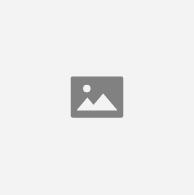

In [33]:
# Dataset report updated, style alignment with model report
from hana_ml.visualizers.unified_report import UnifiedReport

UnifiedReport(sbook_ticketprice).build(key='ID').display()

## Text Processing

### Model based text classification

In [34]:
# Preparing text classification simple sample data
data = pd.DataFrame({"ID" : ['doc1', 'doc2', 'doc3', 'doc4', 'doc5', 'doc6'],
                     "CONTENT" : ['term1 term2 term2 term3 term3 term3',
                                  'term2 term3 term3 term4 term4 term4',
                                  'term3 term4 term4 term5 term5 term5',
                                  'term3 term4 term4 term5 term5 term5 term5 term5 term5',
                                  'term4 term6',
                                  'term4 term6 term6 term6'],
                     "CATEGORY" : ['CATEGORY_1', 'CATEGORY_1', 'CATEGORY_2', 'CATEGORY_2', 'CATEGORY_3', 'CATEGORY_3']})
df_cloud = create_dataframe_from_pandas(connection_context=cc, pandas_df=data, table_name="TM_DEMO", force=True)
print(df_cloud.collect())

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 25.52it/s]

     ID                                            CONTENT    CATEGORY
0  doc1                term1 term2 term2 term3 term3 term3  CATEGORY_1
1  doc2                term2 term3 term3 term4 term4 term4  CATEGORY_1
2  doc3                term3 term4 term4 term5 term5 term5  CATEGORY_2
3  doc4  term3 term4 term4 term5 term5 term5 term5 term...  CATEGORY_2
4  doc5                                        term4 term6  CATEGORY_3
5  doc6                            term4 term6 term6 term6  CATEGORY_3


In [36]:
from hana_ml.text.tm import TextClassificationWithModel
# Step 1. Initialize a TextClassification instance, including basic configs for TF-IDF vectorizer and RDT classifier
tc = TextClassificationWithModel(language='EN',  enable_stopwords=True, keep_numeric=False,
                                         allowed_list=["doc1", "doc2", "doc3", "doc4", "doc5", "doc6"])

# Step 2. Call TextClassification fit() method with training data as input, which is equivalent to applying TF-IDF analysis to the training data firstly, and then building an RDT classifier upon the TF-IDF vectorized training data. 
tc.fit(data=df_cloud, seed=1001, thread_ratio=0.5) 

# Step 3. Predict the labels the text data with the previously trained instance of TextClassification using TF-IDF vectorization and RDT classification.
prediction = tc.predict(data=df_cloud.drop(['CATEGORY']), thread_ratio=0.5, rdt_top_n=1) 


In [37]:
display(prediction.collect())


,ID,TARGET
0,doc2,CATEGORY_1
1,doc5,CATEGORY_3
2,doc3,CATEGORY_2
3,doc6,CATEGORY_3
4,doc1,CATEGORY_1
5,doc4,CATEGORY_2


# Appendix

In [ ]:
# Some display settings
import pandas as pd
pd.set_option('max_colwidth', None) 